# Assignment 5
### Do all four questions.

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [2]:
def download_data(force=False):
    """Download and extract course data from Zenodo."""
    import urllib.request
    import zipfile
    import os
    
    zip_path = 'data.zip'
    data_dir = 'data'
    
    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/16954427/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")
    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")
    
    return data_dir

download_data()

Download complete


'data'

In [1]:
import numpy as np

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [4]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

In [5]:
A@e_1, A@e_2, A@e_3

(array([1, 4, 7]), array([2, 5, 8]), array([3, 6, 9]))

In [ ]:
"""
For each matrix mult, you get the column of A corresponding to the position of the 1 in the vector
"""

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [7]:
u = np.ones(3)

In [8]:
A@u

array([ 6., 15., 24.])

In [ ]:
"""
This gives you a vector where each entry is the sum of the corresponding row in A.
"""

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [11]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])

A@x


array([-2,  4, 11])

In [ ]:
"""
here, since A is the identity matrix, the result is just x, as you are just multiplying each entry in x by 1 at position i in A.
because they are in a diagonal, it goes (-2*1 + 4*0 + 11*0) and so on.
"""

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [14]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x = np.array([-2,4,11])

print(A@x)

B = np.array([[0,1,0],
              [0,0,1],
              [1,0,0]])
print(B@x)


[11 -2  4]
[ 4 11 -2]


In [ ]:
"""
this just shifts the entries in x according to where the 1s are in the matrix.
"""

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [15]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)

[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]


In [ ]:
"""
Each column j of A shows the probability distribution of moving from state j to each possible “next” state.
"""

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [20]:
for e in [e_1, e_2, e_3]:
    v = e.copy()
    for k in range(5):
        v = A @ v
    print(v)

[0.29266551 0.27862515 0.42870935]
[0.29197422 0.27979983 0.42822595]
[0.29171646 0.2802254  0.42805814]


In [ ]:
"""
the transition probabilities converge to a steady state distribution regardless of the initial state.
"""

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


In [21]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

In [22]:
e1 = np.array([1.0, 0.0])  # start in state 1
e2 = np.array([0.0, 1.0])  # start in state 2

In [ ]:
#1
x = e1
x1 = T @ x        
x1

array([0.25, 0.75])

In [24]:
#2
x2 = T @ x1       # [0.4375, 0.5625]
print(x2)

[0.4375 0.5625]


In [ ]:
#3
x = e1.copy()
for _ in range(10):
    x = T @ x
print(x) 

#barely changes after 4/5 iterations

[0.40000057 0.59999943]


In [30]:
#4
x = e2
x1 = T @ x        
x1

array([0.5, 0.5])

In [31]:
#5
x2 = T @ x1      
print(x2)

[0.375 0.625]


In [ ]:
#6
x = e2.copy()
for _ in range(5):
    x = T @ x
print(x) 

#the results converge to the same distribution as before


[0.40039062 0.59960938]


3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

In [36]:
import pandas as pd

In [37]:
weather = pd.read_csv('/Users/ethanmeidinger/ds5030/data/cville_weather.csv')

In [38]:
weather

,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES
0,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-04,NaN,NaN,NaN,NaN,0.03,",,N",NaN,NaN,NaN,NaN
1,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-07,NaN,NaN,NaN,NaN,1.08,",,N",NaN,NaN,NaN,NaN
2,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-09,NaN,NaN,NaN,NaN,0.24,",,N",NaN,NaN,NaN,NaN
3,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-10,NaN,NaN,NaN,NaN,3.00,",,N",NaN,NaN,NaN,NaN
4,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-24,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-27,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
407,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-28,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
408,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-29,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
409,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-30,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN


In [40]:
weather['PRCP'] = weather['PRCP'].fillna(0)
weather['rain'] = (weather['PRCP'] > 0).astype(int)
weather[['PRCP', 'rain']].head()

,PRCP,rain
0,0.03,1
1,1.08,1
2,0.24,1
3,3.00,1
4,0.00,0


In [41]:
rain = weather['rain'].values
n = len(rain)

# transitions: yesterday to today
transitions = np.zeros((2, 2))

for t in range(1, n):
    prev = rain[t-1]
    curr = rain[t]
    transitions[curr, prev] += 1

T = transitions / transitions.sum(axis=0)
T

array([[0.73160173, 0.35195531],
       [0.26839827, 0.64804469]])

In [42]:
p_rain_given_rainy_yesterday = T[1, 1]
p_rain_given_clear_yesterday = T[1, 0]

#bayes
print("P(rain today | rain yesterday):", round(p_rain_given_rainy_yesterday, 3))
print("P(rain today | clear yesterday):", round(p_rain_given_clear_yesterday, 3))

P(rain today | rain yesterday): 0.648
P(rain today | clear yesterday): 0.268


In [43]:
x_clear = np.array([1.0, 0.0])  # start clear
x_rainy = np.array([0.0, 1.0])  # start rainy

def forecast_chain(T, x0, steps=10):
    x = x0.copy()
    traj = [x.copy()]
    for _ in range(steps):
        x = T @ x
        traj.append(x.copy())
    return np.array(traj)

forecast_clear = forecast_chain(T, x_clear)
forecast_rainy = forecast_chain(T, x_rainy)

pd.DataFrame(forecast_clear, columns=['Clear', 'Rain']).head(10)

,Clear,Rain
0,1.000000,0.000000
1,0.731602,0.268398
2,0.629705,0.370295
3,0.591021,0.408979
4,0.576334,0.423666
5,0.570759,0.429241
6,0.568642,0.431358
7,0.567838,0.432162
8,0.567533,0.432467
9,0.567417,0.432583


In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

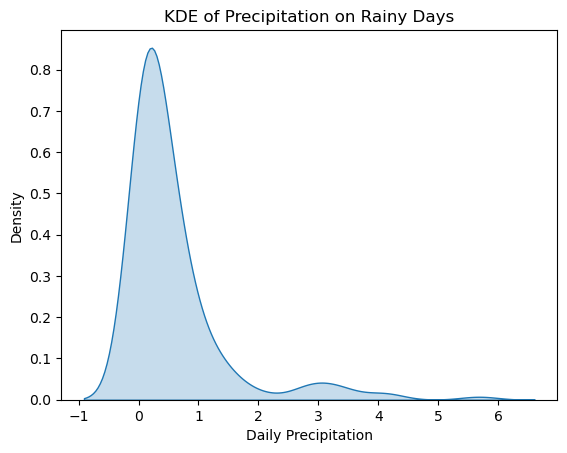

In [48]:
sns.kdeplot(data=weather[weather['rain'] == 1], x='PRCP', fill=True)
plt.title("KDE of Precipitation on Rainy Days")
plt.xlabel("Daily Precipitation")
plt.show()

In [49]:
#we could potentially improve this model by including a second order markov chain, where the weather two days ago also influences the weather today.

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [62]:
import pickle

In [63]:
path = '/Users/ethanmeidinger/ds5030/data/taxicab.pkl'
traj_list = pd.read_pickle(path) 

def clean_series(s):
    s = pd.Series(s).dropna().astype(str)
    # keep length>=2 for transitions
    return s if len(s) >= 2 else None

traj_clean = [clean_series(s) for s in traj_list]
traj_clean = [s for s in traj_clean if s is not None]

In [64]:
states = sorted(pd.unique(pd.Index(np.concatenate([s.values for s in traj_clean]))))
idx = {nb:i for i,nb in enumerate(states)}
n = len(states)

In [66]:
counts = np.zeros((n, n), dtype=float)
for s in traj_clean:
    a = s.values[:-1]
    b = s.values[ 1:]
    for fr, to in zip(a, b):
        counts[idx[to], idx[fr]] += 1.0

In [68]:
T = counts / counts.sum(axis=0)
T_df = pd.DataFrame(T, index=states, columns=states)

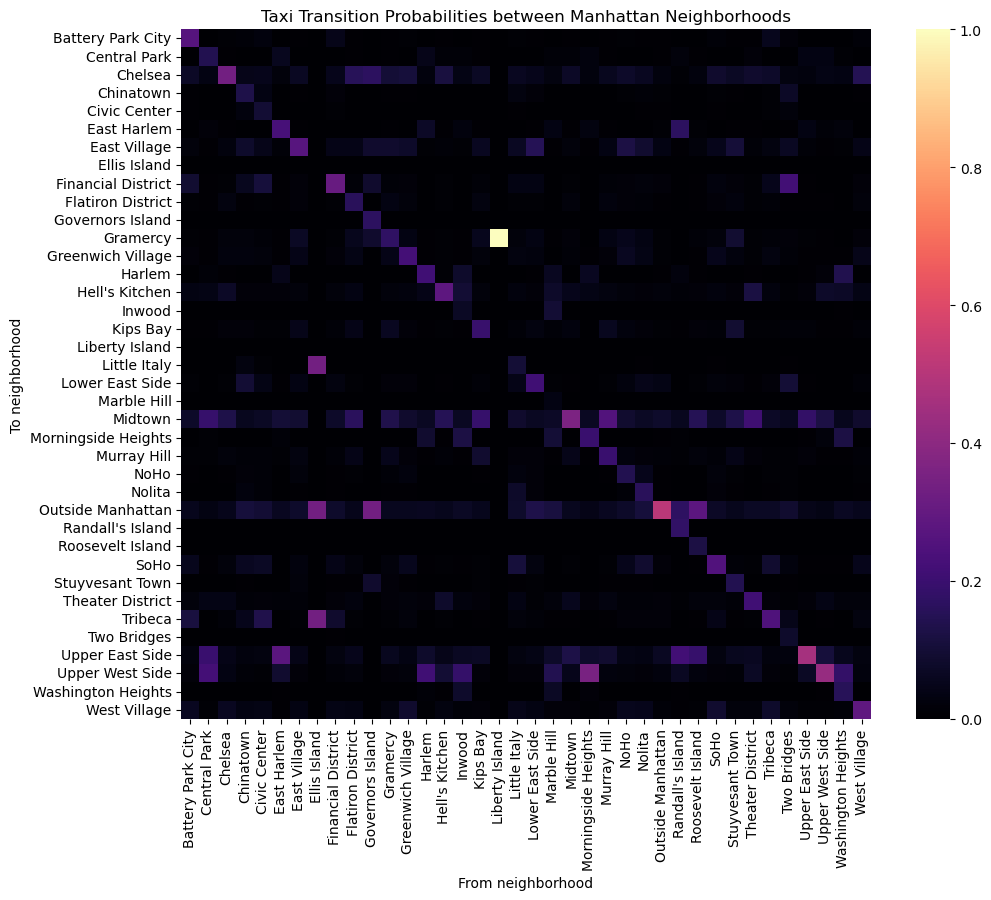

In [ ]:
plt.figure(figsize=(11,9))
sns.heatmap(T_df, cmap='magma', square=True)
plt.title("Taxi Transition Probabilities between Manhattan Neighborhoods")
plt.ylabel("To neighborhood")
plt.xlabel("From neighborhood")
plt.tight_layout()
plt.show()

#looks like liberty island to gramercy is by far the most probable transition

In [ ]:
#because each taxi ride is a distinct ride with a new person, the rides are independent of each other,
#making them order 1

In [70]:
def forecast(T, x0, k):
    v = x0.copy()
    for _ in range(k):
        v = T @ v
    return v

def show_forecast(start_nbhd, steps=[2,3,5,10], top=5):
    x0 = np.zeros(n); x0[idx[start_nbhd]] = 1.0
    for k in steps:
        vk = forecast(T, x0, k)
        s = pd.Series(vk, index=states).sort_values(ascending=False)
        print(f"\n{k}-trip forecast starting at {start_nbhd}:")
        print(s.head(top).round(3))

show_forecast("Hell's Kitchen", steps=[2,3,5,10], top=8)


2-trip forecast starting at Hell's Kitchen:
Midtown              0.173
Hell's Kitchen       0.119
Chelsea              0.109
Upper West Side      0.099
Upper East Side      0.087
Outside Manhattan    0.078
Theater District     0.060
West Village         0.035
dtype: float64

3-trip forecast starting at Hell's Kitchen:
Midtown              0.173
Upper East Side      0.108
Chelsea              0.097
Upper West Side      0.092
Outside Manhattan    0.090
Hell's Kitchen       0.075
Theater District     0.047
West Village         0.036
dtype: float64

5-trip forecast starting at Hell's Kitchen:
Midtown              0.169
Upper East Side      0.120
Outside Manhattan    0.099
Chelsea              0.088
Upper West Side      0.083
Hell's Kitchen       0.057
Theater District     0.040
East Village         0.037
dtype: float64

10-trip forecast starting at Hell's Kitchen:
Midtown              0.168
Upper East Side      0.122
Outside Manhattan    0.103
Chelsea              0.086
Upper West Side   

In [73]:
x = np.ones(n) / n
tol = 1e-8
for _ in range(1000):
    x_next = T @ x
    if np.linalg.norm(x_next - x, 1) < tol:
        break
    x = x_next

pi = x / x.sum()
pi_s = pd.Series(pi, index=states).sort_values(ascending=False)

print(pi_s.head(4).round(4))

Midtown              0.1677
Upper East Side      0.1218
Outside Manhattan    0.1030
Chelsea              0.0862
dtype: float64


In [ ]:
#inside manhattan, the neighborhoods with the highest long-term taxi distribution are Midtown, Upper East Side, and Chelsea